In [43]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import h5py
from mne_bids import BIDSPath


In [44]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)


# Aim 2 — helpers

Grant conventions: **AIC-focused** (red), control ROIs = STG / SMC, **no PIC / no dACC**.
Outputs → `grantfig/aim2_*.svg`.


In [45]:
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

REF = 'bipolar'
GRANTFIG = Path('grantfig')
GRANTFIG.mkdir(exist_ok=True)

GRANT_ROIS = ['AIC', 'STG', 'SMC']
GRANT_ROI_COLORS = {
    'AIC': red,
    'STG': 'darkgray',
    'SMC': 'black',
}
GRANT_ROI_PALETTE = [GRANT_ROI_COLORS[r] for r in GRANT_ROIS]

LEXICAL_PHASES = ['Stimulus', 'Delay', 'Go', 'Response']
PHONEME_SEQUENCE_PHASES = ['Stimulus', 'Delay', 'Go', 'Response']
TEMPORAL_XTICKS = [0, 0.5, 1]


def _roi_from_bids_subject(subject):
    hemi = 'Left' if subject[-1].lower() == 'l' else 'Right'
    roi = subject[:-1]
    return roi, hemi


def load_window_decoding(task, decode_type, description='Repeat'):
    decode_path = BIDSPath(
        datatype=f'(decode){decode_type}',
        root=f'../results/{task}(roi)({REF})',
        suffix='highgamma',
        check=False,
    ).match()

    scores = []
    for path in decode_path:
        with h5py.File(path, 'r') as mat:
            acc = mat['accuracy'][()]
            p_value = mat['p_value'][()]
            perm_scores = mat['perm_scores'][()]

        n_folds = acc.shape[0]
        p_value_arr = np.array(p_value)
        if p_value_arr.shape == ():
            p_value_arr = np.repeat(p_value_arr, n_folds)

        roi, hemi = _roi_from_bids_subject(path.subject)
        df = pd.DataFrame({
            'fold': np.arange(n_folds),
            'score': acc,
            'p_value': p_value_arr,
            'perm': perm_scores.mean(axis=1),
            'roi': roi,
            'hemi': hemi,
            'description': path.description,
            'phase': path.processing,
            'recording': path.recording,
            'decode_type': decode_type,
            'task': task,
        })
        scores.append(df)

    scores = pd.concat(scores, ignore_index=True)
    scores = scores[scores.description == description]
    scores = scores[scores.roi.isin(GRANT_ROIS)]
    return scores


def load_temporal_resolved_decoding(task, decode_type, description='Repeat', smooth_sigma=2):
    result_path = BIDSPath(
        datatype=f'(decode)(resolved){decode_type}',
        root=f'../results/{task}(roi)({REF})',
        suffix='highgamma',
        check=False,
    ).match()

    scores = []
    for path in result_path:
        with h5py.File(path, 'r') as mat:
            accuracy = mat['accuracy'][()]
            time = mat['time'][()]
            p_value = mat['p_values'][()]
            baseline = mat['baseline'][()]

        n_time, n_fold = accuracy.shape
        baseline_mean = baseline.mean(axis=-1)
        accuracy = gaussian_filter1d(accuracy, sigma=smooth_sigma, axis=0, mode='nearest')

        df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
        df_acc = df_acc.rename(columns={'index': 'time'})
        df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
        df_base = df_base.rename(columns={'index': 'time'})

        df_acc = df_acc.melt(id_vars='time', var_name='fold', value_name='accuracy')
        df_base = df_base.melt(id_vars='time', var_name='fold', value_name='baseline')
        df = df_acc.merge(df_base, on=['time', 'fold'], how='left')
        df = df.merge(pd.DataFrame({'time': time, 'p_value': p_value}), on='time', how='left')

        roi, hemi = _roi_from_bids_subject(path.subject)
        df['roi'] = roi
        df['phase'] = path.processing
        df['hemi'] = hemi
        df['description'] = path.description
        df['decode_type'] = decode_type
        df['task'] = task
        scores.append(df)

    scores = pd.concat(scores, ignore_index=True)
    scores = scores[scores.description == description]
    scores = scores[scores.roi.isin(GRANT_ROIS)]
    return scores


def load_cross_generalized_decoding(task, decode_type='lexicality', smooth_sigma=1):
    result_path = BIDSPath(
        datatype=f'(cross)(generalized){decode_type}',
        root=f'../results/{task}(roi)({REF})',
        suffix='highgamma',
        check=False,
    ).match()

    scores = []
    for path in result_path:
        with h5py.File(path, 'r') as mat:
            accuracy = mat['scores'][()]
            train_time = mat['train_time'][()]
            test_time = mat['test_time'][()]
            p_map = mat['p_values_cluster'][()]
            baseline = mat['baseline'][()]

        n_train, n_test, n_fold = accuracy.shape
        baseline_mean = baseline.mean(axis=3)
        accuracy_smooth = gaussian_filter(accuracy, sigma=(smooth_sigma, smooth_sigma, 0), mode='nearest')

        Ttrain, Ttest = np.meshgrid(train_time, test_time, indexing='ij')
        df_acc = pd.DataFrame(accuracy_smooth.reshape(-1, n_fold), columns=range(n_fold))
        df_acc['train_time'] = Ttrain.flatten()
        df_acc['test_time'] = Ttest.flatten()
        df_acc = df_acc.melt(id_vars=['train_time', 'test_time'], var_name='fold', value_name='accuracy')

        df_p = pd.DataFrame({
            'train_time': Ttrain.flatten(),
            'test_time': Ttest.flatten(),
            'p_value': p_map.reshape(-1),
        })
        df_base = pd.DataFrame({
            'train_time': Ttrain.flatten(),
            'test_time': Ttest.flatten(),
            'baseline': baseline_mean.mean(axis=2).reshape(-1),
        })

        df = df_acc.merge(df_p, on=['train_time', 'test_time'], how='left')
        df = df.merge(df_base, on=['train_time', 'test_time'], how='left')

        roi, hemi = _roi_from_bids_subject(path.subject)
        if '2' in path.description:
            train_on, test_on = path.description.split('2')
        else:
            train_on = test_on = path.description

        df['roi'] = roi
        df['phase'] = path.processing
        df['hemi'] = hemi
        df['train_on'] = train_on
        df['test_on'] = test_on
        df['decode_type'] = decode_type
        df['task'] = task
        scores.append(df)

    scores = pd.concat(scores, ignore_index=True)
    scores = scores[scores.roi.isin(GRANT_ROIS)]
    return scores


def _style_axes(ax):
    ax.tick_params(labelsize=fontsize, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, trim=True, offset=0.2)


def _plot_temporal_row(
    ax_row, scores, phases, chance, hemi='Left', xlim=(-0.2, 1.0),
    ymax=None, ymin=None, sig_p=0.05,
):
    if ymax is None:
        ymax = 0.85 if chance >= 0.4 else 0.55
    if ymin is None:
        ymin = 0.45 if chance >= 0.4 else chance - 0.05

    pad, bar_h = 0.01, 0.02
    y_top = ymax + pad + len(GRANT_ROIS) * (bar_h + 0.005) + 0.02

    for j, phase in enumerate(phases):
        ax = ax_row[j]
        subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
        sns.lineplot(
            data=subset, x='time', y='accuracy', hue='roi',
            palette=GRANT_ROI_PALETTE, hue_order=GRANT_ROIS,
            lw=1, ax=ax, legend=(j == 0), errorbar='se',
        )
        for k, roi in enumerate(GRANT_ROIS):
            roi_data = subset[(subset.roi == roi) & (subset.fold == 0)].sort_values('time')
            if roi_data.empty:
                continue
            mask = roi_data['p_value'].values < sig_p
            offset = k * (bar_h + 0.005)
            if mask.any():
                ax.fill_between(
                    roi_data['time'].values,
                    ymax + pad + offset, ymax + pad + bar_h + offset,
                    where=mask, color=GRANT_ROI_PALETTE[k], alpha=1, step='mid', linewidth=0,
                )
        ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
        ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
        ax.set_xlim(*xlim)
        ax.set_ylim(ymin, y_top)
        ax.set_xticks(TEMPORAL_XTICKS)
        ax.set_title(phase.capitalize(), fontsize=fontsize)
        ax.set_xlabel('')
        _style_axes(ax)
        if j == 0:
            ax.set_ylabel('Accuracy', fontsize=fontsize)
        else:
            ax.set_yticks([])
            ax.spines['left'].set_visible(False)
            ax.set_ylabel('')


def plot_temporal_decoding(scores, phases, chance, hemi='Left', xlim=(-0.2, 1.0),
                           ymax=None, ymin=None, sig_p=0.05, save_path=None):
    n_phases = len(phases)
    fig, axes = plt.subplots(1, n_phases, figsize=(3.2 * n_phases * cm, 3 * cm))
    if n_phases == 1:
        axes = [axes]
    _plot_temporal_row(axes, scores, phases, chance, hemi=hemi, xlim=xlim,
                       ymax=ymax, ymin=ymin, sig_p=sig_p)
    for ax in axes[1:]:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_ylabel('')
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    if axes[0].get_legend() is not None:
        axes[0].legend(fontsize=fontsize, title='')
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig


def _plot_window_perception_production(scores, chance, lim, save_path=None):
    """Stimulus vs Response window decoding scatter."""
    id_cols = ['roi', 'hemi']
    per = scores[(scores.phase == 'Stimulus') & (scores.p_value < 0.05)].groupby(id_cols)['score'].mean()
    pro = scores[(scores.phase == 'Response') & (scores.p_value < 0.05)].groupby(id_cols)['score'].mean()
    wide = pd.concat({'perception': per, 'production': pro}, axis=1).dropna().reset_index()
    wide = wide[wide.roi.isin(GRANT_ROIS)]

    fig, ax = plt.subplots(figsize=(5 * cm, 5 * cm))

    for hemi in ['Left', 'Right']:
        sub = wide[wide.hemi == hemi]
        for _, row in sub.iterrows():
            c = GRANT_ROI_COLORS[row['roi']]
            if hemi == 'Right':
                ax.scatter(
                    row['production'], row['perception'],
                    marker='P', s=30, facecolors='none', edgecolors=c, linewidth=1, zorder=3,
                )
            else:
                ax.scatter(
                    row['production'], row['perception'],
                    marker='o', s=30, facecolors=c, edgecolors='k', linewidth=0.5, zorder=3,
                )

    ax.plot(lim, lim, ls='--', c='gray', lw=0.75, zorder=0)
    ax.axvline(x=chance, ls='--', c='gray', lw=0.75)
    ax.axhline(y=chance, ls='--', c='gray', lw=0.75)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel('Production accuracy', fontsize=fontsize)
    ax.set_ylabel('Perception accuracy', fontsize=fontsize)
    handles = [
        Line2D([0], [0], marker='o', linestyle='', markerfacecolor=GRANT_ROI_COLORS[r],
               markeredgecolor='k', markersize=5, label=r)
        for r in GRANT_ROIS
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=6, frameon=False)
    _style_axes(ax)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig


def plot_articulator_perception_production(scores, save_path=None):
    """2.1A: articulatory window decoding (Stimulus vs Response)."""
    return _plot_window_perception_production(scores, chance=1 / 4, lim=(0.2, 0.75), save_path=save_path)


def plot_phoneme_perception_production(scores, save_path=None):
    """2.1A: phoneme window decoding (Stimulus vs Response, recording-1)."""
    scores = scores[scores.recording == '1']
    return _plot_window_perception_production(scores, chance=1 / 8, lim=(0.1, 0.55), save_path=save_path)


def plot_cross_overlay(df, phase='Delay', train_on='Repeat', test_on='Decision', roi='AIC', save_path=None):
    import scipy.ndimage

    tmp_df = df[(df.phase == phase) & (df.train_on == train_on) & (df.test_on == test_on) & (df.roi == roi)]
    if tmp_df.empty:
        print(f'No cross-decode data for {roi} | {phase} | {train_on}->{test_on}')
        return None

    train_times = sorted(tmp_df.train_time.unique())
    test_times = sorted(tmp_df.test_time.unique())

    fig, ax = plt.subplots(figsize=(6 * cm, 6 * cm))
    ax.plot([train_times[0], train_times[-1]], [test_times[0], test_times[-1]], color='black', linestyle='--', linewidth=0.75)
    if train_times[0] <= 0 <= train_times[-1]:
        ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.75)
    if test_times[0] <= 0 <= test_times[-1]:
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.75)

    acc_map = tmp_df.groupby(['train_time', 'test_time'])['accuracy'].mean().unstack().values
    p_map = tmp_df.groupby(['train_time', 'test_time'])['p_value'].mean().unstack().values
    if 'baseline' in tmp_df.columns:
        base_map = tmp_df.groupby(['train_time', 'test_time'])['baseline'].mean().unstack().values
    else:
        base_map = np.ones_like(acc_map) * 0.5

    sig_mask = (p_map < 0.05) & (acc_map > base_map)
    labeled_array, num_features = scipy.ndimage.label(sig_mask)
    filtered_mask = np.zeros_like(sig_mask)
    for lbl in range(1, num_features + 1):
        if np.sum(labeled_array == lbl) >= 4:
            filtered_mask[labeled_array == lbl] = 1

    if np.any(filtered_mask):
        ax.contourf(train_times, test_times, filtered_mask.T, levels=[0.5, 1.5], colors=[red], alpha=0.55)
        ax.contour(train_times, test_times, filtered_mask.T, levels=[0.5], colors=[red], linewidths=0.75)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ticks = np.arange(-0.5, 1.6, 0.5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f'Train time ({train_on})', fontsize=fontsize)
    ax.set_ylabel(f'Test time ({test_on})', fontsize=fontsize)
    ax.set_title(f'AIC — {phase}: {train_on} → {test_on}', fontsize=fontsize)
    _style_axes(ax)
    fig.subplots_adjust(left=0.18, bottom=0.15, right=0.95, top=0.88)
    if save_path:
        fig.savefig(save_path, dpi=300)
    return fig

print('Aim 2 helpers loaded.')


Aim 2 helpers loaded.


# Aim 2.1 — Encoding / decoding of linguistic and articulatory content


### 2.1A — Articulatory window decoding (perception vs production)


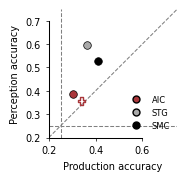

Saved grantfig/aim2_1a_articulator_window.svg


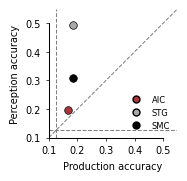

Saved grantfig/aim2_1a_phoneme_window.svg


In [46]:
# --- 2.1A: Articulatory window decoding (PhonemeSequence, Repeat) ---
artic_scores = load_window_decoding('PhonemeSequence', 'articulator', description='Repeat')
fig = plot_articulator_perception_production(
    artic_scores,
    save_path=GRANTFIG / 'aim2_1a_articulator_window.svg',
)
plt.show()
print('Saved', GRANTFIG / 'aim2_1a_articulator_window.svg')

# --- 2.1A: Phoneme window decoding (PhonemeSequence, Repeat, recording-1) ---
phoneme_scores = load_window_decoding('PhonemeSequence', 'phoneme', description='Repeat')
fig = plot_phoneme_perception_production(
    phoneme_scores,
    save_path=GRANTFIG / 'aim2_1a_phoneme_window.svg',
)
plt.show()
print('Saved', GRANTFIG / 'aim2_1a_phoneme_window.svg')

### 2.1C — Lexicality temporal decoding (Repeat)


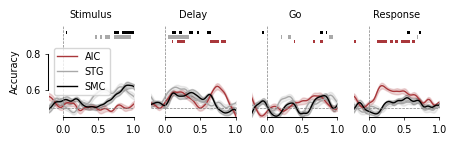

Saved grantfig/aim2_1c_lexicality_repeat_temporal.svg


In [53]:
lex_repeat = load_temporal_resolved_decoding('LexicalDelay', 'lexicality', description='Repeat')
fig = plot_temporal_decoding(
    lex_repeat,
    phases=LEXICAL_PHASES,
    chance=0.5,
    xlim=(-0.2, 0.85),
    save_path=GRANTFIG / 'aim2_1c_lexicality_repeat_temporal.svg',
)
plt.show()
print('Saved', GRANTFIG / 'aim2_1c_lexicality_repeat_temporal.svg')

### 2.1D — Lexicality temporal decoding (Decision)


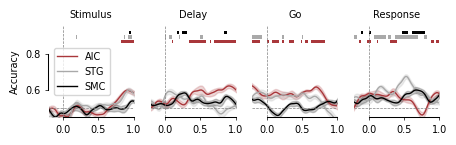

Saved grantfig/aim2_1d_lexicality_decision_temporal.svg


In [54]:
lex_decision = load_temporal_resolved_decoding('LexicalDelay', 'lexicality', description='Decision')
fig = plot_temporal_decoding(
    lex_decision,
    phases=LEXICAL_PHASES,
    chance=0.5,
    xlim=(-0.2, 0.85),
    save_path=GRANTFIG / 'aim2_1d_lexicality_decision_temporal.svg',
)
plt.show()
print('Saved', GRANTFIG / 'aim2_1d_lexicality_decision_temporal.svg')


# Aim 2.2 — Cross-task generalization


### 2.2B — Cross-condition Repeat → Decision (2D generalization overlay, AIC Delay)


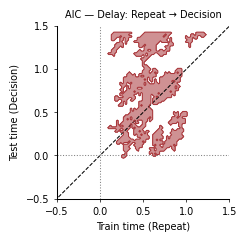

Saved grantfig/aim2_2b_cross_repeat2decision_delay.svg


In [52]:
cross_scores = load_cross_generalized_decoding('LexicalDelay', 'lexicality')

fig = plot_cross_overlay(
    cross_scores,
    phase='Delay',
    train_on='Repeat',
    test_on='Decision',
    roi='AIC',
    save_path=GRANTFIG / 'aim2_2b_cross_repeat2decision_delay.svg',
)
if fig is not None:
    plt.show()
    print('Saved', GRANTFIG / 'aim2_2b_cross_repeat2decision_delay.svg')